## Testing Other Models — Binary At-Risk, Fine-tuned tại T=150

Gộp **Fail** + **Withdrawn** thành **At-risk (1)**, **Pass → 0**. Chỉ dùng sinh viên **còn active tại T=150** (snapshot `prediction_point == 150`).

- **Models**: Logistic Regression, Random Forest, CatBoost, LightGBM
  - *SVM (RBF) được bỏ qua*: không khả thi trên dữ liệu lớn.
- **Fine-tune (Optuna) cho từng model**:
  - Tune đồng thời: hyperparameter của model + **SMOTE ratio** (At-risk) + **class_weight** (At-risk).
  - Tối ưu **F1-score At-risk** (pos_label=1) qua **StratifiedKFold** (3-fold).
- **Scaling**: chỉ **Logistic Regression** được scale (`StandardScaler` fit trên train-fold để tránh leakage).
- **Metric**: Confusion matrix, classification report, ROC-AUC cho từng model + bảng tổng hợp precision / recall / f1 (lớp **At-risk**), accuracy, ROC-AUC.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))
from config import RANDOM_SEED

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, accuracy_score, roc_auc_score,
)

TARGET_NAMES = ['Pass', 'At-risk']
CLASSES = [0, 1]

In [2]:
data_dir = Path('../data/processed')
FIG_DIR  = Path('../full_report/figures'); FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR  = Path('../full_report'); RES_DIR.mkdir(parents=True, exist_ok=True)

PREDICTION_POINT = 150  # chỉ giữ sinh viên còn active tại T=150

X_train_all = pd.read_parquet(data_dir / 'X_train.parquet')
X_test_all  = pd.read_parquet(data_dir / 'X_test.parquet')
y_train_all = pd.read_parquet(data_dir / 'y_train.parquet').squeeze()
y_test_all  = pd.read_parquet(data_dir / 'y_test.parquet').squeeze()
train_meta  = pd.read_parquet(data_dir / 'train_meta.parquet')
test_meta   = pd.read_parquet(data_dir / 'test_meta.parquet')

# Lọc về snapshot T=150 (sinh viên withdraw <= 150 ngày đã bị loại khỏi snapshot này)
mask_tr = (train_meta['prediction_point'] == PREDICTION_POINT).values
mask_te = (test_meta['prediction_point'] == PREDICTION_POINT).values

X_train = X_train_all[mask_tr].reset_index(drop=True).fillna(0)
X_test  = X_test_all[mask_te].reset_index(drop=True).fillna(0)
y_train = y_train_all[mask_tr].reset_index(drop=True)
y_test  = y_test_all[mask_te].reset_index(drop=True)

# Gộp Fail (0) + Withdrawn (2) -> At-risk (1); Pass (1) -> 0
LABEL_MAP = {0: 1, 1: 0, 2: 1}
y_train = y_train.map(LABEL_MAP)
y_test  = y_test.map(LABEL_MAP)

print('Prediction point:', PREDICTION_POINT)
print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('Features:', list(X_train.columns))
print('Train dist:', y_train.value_counts().rename({0: 'Pass', 1: 'At-risk'}).to_dict())
print('Test  dist:', y_test.value_counts().rename({0: 'Pass', 1: 'At-risk'}).to_dict())


Prediction point: 150
X_train: (17386, 15) | X_test: (4363, 15)
Features: ['highest_education', 'disability', 'num_of_prev_attempts', 'studied_credits', 'total_clicks_filled', 'active_weeks_filled', 'avg_weekly_clicks_filled', 'num_due', 'num_submitted_filled', 'avg_score_filled', 'num_failed_filled', 'avg_days_early_filled', 'no_submission_despite_due', 'imd_band_filled', 'imd_missing']
Train dist: {'Pass': 11067, 'At-risk': 6319}
Test  dist: {'Pass': 2804, 'At-risk': 1559}


### Cấu hình model + search space

Mỗi model có: `needs_scaling`, hàm `suggest` (search space hyperparameter cho Optuna), và hàm `make` (tạo estimator với class_weight At-risk). SMOTE ratio và class_weight được tune chung cho mọi model.

In [3]:
N_TRIALS = 30  # số trial Optuna mỗi model (giảm nếu muốn chạy nhanh hơn)

# Ghi lại siêu tham số tối ưu (CV F1, SMOTE ratio, class_weight) theo (bộ đặc trưng, model)
TUNING_LOG  = {}
CURRENT_SET = 'Full (15)'

# Tên file hình cho ma trận nhầm lẫn từng model (bộ đặc trưng đầy đủ)
CM_FILES = {
    'Logistic Regression': 'cm_logreg_full.png',
    'Random Forest':       'cm_rf_full.png',
    'CatBoost':            'cm_catboost_full.png',
    'LightGBM':            'cm_lgbm_full.png',
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)


def safe_smote_bin(X, y, ratio_at_risk):
    """Oversample At-risk: new_count = int((1 + ratio) * N_current), ratio ∈ [0.1, 0.9]."""
    y_arr = np.asarray(y)
    n_at_risk = int((y_arr == 1).sum())
    target = {1: int((1 + ratio_at_risk) * n_at_risk)}
    k = max(1, min(5, n_at_risk - 1))
    sm = SMOTE(sampling_strategy=target, random_state=RANDOM_SEED, k_neighbors=k)
    return sm.fit_resample(np.asarray(X), y_arr)


# --- Search space + estimator factory cho từng model ---
def suggest_logreg(trial):
    return {'C': trial.suggest_float('C', 1e-3, 1e2, log=True)}

def make_logreg(params, w):
    return LogisticRegression(C=params['C'], max_iter=1000,
                              class_weight={0: 1.0, 1: w}, random_state=RANDOM_SEED)


def suggest_rf(trial):
    return {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 400),
        'max_depth':        trial.suggest_int('max_depth', 4, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2']),
    }

def make_rf(params, w):
    return RandomForestClassifier(**params, class_weight={0: 1.0, 1: w},
                                  random_state=RANDOM_SEED, n_jobs=-1)


def suggest_cat(trial):
    return {
        'iterations':    trial.suggest_int('iterations', 200, 600),
        'depth':         trial.suggest_int('depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg':   trial.suggest_float('l2_leaf_reg', 1.0, 10.0, log=True),
    }

def make_cat(params, w):
    return CatBoostClassifier(**params, class_weights=[1.0, w],
                              random_state=RANDOM_SEED, verbose=0)


def suggest_lgbm(trial):
    return {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'num_leaves':        trial.suggest_int('num_leaves', 15, 63),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
    }

def make_lgbm(params, w):
    return LGBMClassifier(**params, class_weight={0: 1.0, 1: w},
                          random_state=RANDOM_SEED, n_jobs=-1, verbose=-1)


MODEL_CONFIGS = {
    'Logistic Regression': dict(needs_scaling=True,  suggest=suggest_logreg, make=make_logreg),
    'Random Forest':       dict(needs_scaling=False, suggest=suggest_rf,     make=make_rf),
    'CatBoost':            dict(needs_scaling=False, suggest=suggest_cat,    make=make_cat),
    'LightGBM':            dict(needs_scaling=False, suggest=suggest_lgbm,   make=make_lgbm),
}
list(MODEL_CONFIGS)

['Logistic Regression', 'Random Forest', 'CatBoost', 'LightGBM']

### Fine-tune & đánh giá từng model

Với mỗi model: Optuna (`N_TRIALS` trials) tune hyperparameter + SMOTE ratio + class_weight, tối ưu F1 At-risk qua 3-fold CV → retrain best params trên full train → đánh giá test (confusion matrix + report + ROC-AUC).

> ⚠️ Chạy khá nặng (4 model × Optuna × 3-fold, có SMOTE mỗi fold) — chủ yếu ở CatBoost & Random Forest. Giảm `N_TRIALS` ở cell trên nếu cần nhanh hơn.


############################################################
  FINE-TUNE: Logistic Regression
############################################################


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.7763
SMOTE → At-risk: +0.51x | class_weight At-risk: 1.03


              precision    recall  f1-score   support

        Pass      0.865     0.865     0.865      2804
     At-risk      0.757     0.757     0.757      1559

    accuracy                          0.826      4363
   macro avg      0.811     0.811     0.811      4363
weighted avg      0.826     0.826     0.826      4363



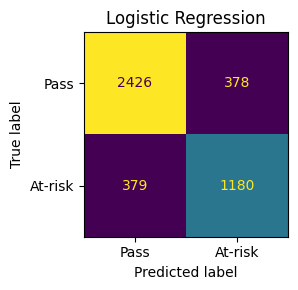

ROC-AUC: 0.8975

############################################################
  FINE-TUNE: Random Forest
############################################################


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.7817
SMOTE → At-risk: +0.36x | class_weight At-risk: 1.88


              precision    recall  f1-score   support

        Pass      0.879     0.872     0.875      2804
     At-risk      0.773     0.783     0.778      1559

    accuracy                          0.840      4363
   macro avg      0.826     0.828     0.827      4363
weighted avg      0.841     0.840     0.841      4363



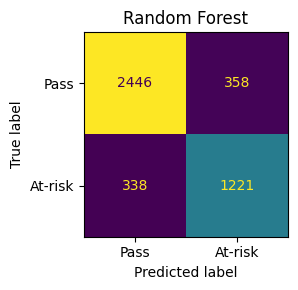

ROC-AUC: 0.9071

############################################################
  FINE-TUNE: CatBoost
############################################################


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.7906
SMOTE → At-risk: +0.57x | class_weight At-risk: 1.33


              precision    recall  f1-score   support

        Pass      0.876     0.895     0.886      2804
     At-risk      0.804     0.773     0.788      1559

    accuracy                          0.851      4363
   macro avg      0.840     0.834     0.837      4363
weighted avg      0.850     0.851     0.851      4363



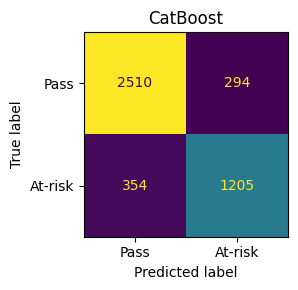

ROC-AUC: 0.9126

############################################################
  FINE-TUNE: LightGBM
############################################################


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.7891
SMOTE → At-risk: +0.10x | class_weight At-risk: 1.46


              precision    recall  f1-score   support

        Pass      0.874     0.885     0.879      2804
     At-risk      0.788     0.770     0.779      1559

    accuracy                          0.844      4363
   macro avg      0.831     0.827     0.829      4363
weighted avg      0.843     0.844     0.843      4363



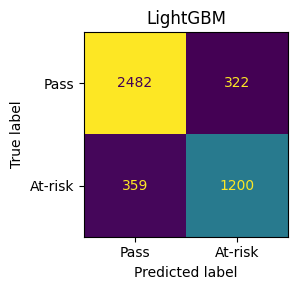

ROC-AUC: 0.9108


In [4]:
def tune_and_evaluate(name, cfg, X_tr, y_tr, X_te, y_te, n_trials=N_TRIALS, plot_cm=True):
    needs_scaling = cfg['needs_scaling']
    Xtr = np.asarray(X_tr); Xte = np.asarray(X_te)
    ytr = np.asarray(y_tr); yte = np.asarray(y_te)

    def objective(trial):
        params = cfg['suggest'](trial)
        ratio  = trial.suggest_float('smote_ratio_at_risk', 0.1, 0.9)
        w      = trial.suggest_float('w_at_risk', 1.0, 8.0)

        scores = []
        for tr_idx, val_idx in cv.split(Xtr, ytr):
            Xf_tr, yf_tr = Xtr[tr_idx], ytr[tr_idx]
            Xf_val, yf_val = Xtr[val_idx], ytr[val_idx]

            if needs_scaling:  # fit scaler chỉ trên train-fold (tránh leakage)
                sc = StandardScaler().fit(Xf_tr)
                Xf_tr, Xf_val = sc.transform(Xf_tr), sc.transform(Xf_val)

            Xf_sm, yf_sm = safe_smote_bin(Xf_tr, yf_tr, ratio)
            m = cfg['make'](params, w)
            m.fit(Xf_sm, yf_sm)
            scores.append(f1_score(yf_val, m.predict(Xf_val), pos_label=1, zero_division=0))
        return float(np.mean(scores))

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    bp = study.best_params
    model_params = {k: v for k, v in bp.items()
                    if k not in ('smote_ratio_at_risk', 'w_at_risk')}
    best_ratio, best_w = bp['smote_ratio_at_risk'], bp['w_at_risk']
    print(f'Best F1 At-risk CV: {study.best_value:.4f}')
    print(f'SMOTE → At-risk: +{best_ratio:.2f}x | class_weight At-risk: {best_w:.2f}')
    TUNING_LOG[f'{CURRENT_SET}|{name}'] = {
        'cv_f1':        round(float(study.best_value), 4),
        'smote_ratio':  round(float(best_ratio), 2),
        'w_at_risk':    round(float(best_w), 2),
        'model_params': model_params,   # để tái tạo mô hình mà không cần tune lại
    }

    # Retrain best params trên full train
    if needs_scaling:
        scaler = StandardScaler().fit(Xtr)
        Xtr_f, Xte_f = scaler.transform(Xtr), scaler.transform(Xte)
    else:
        scaler, Xtr_f, Xte_f = None, Xtr, Xte
    X_sm, y_sm = safe_smote_bin(Xtr_f, ytr, best_ratio)
    final = cfg['make'](model_params, best_w)
    final.fit(X_sm, y_sm)

    y_pred  = final.predict(Xte_f)
    y_proba = final.predict_proba(Xte_f)[:, 1]

    print(classification_report(yte, y_pred, target_names=TARGET_NAMES, digits=3))
    if plot_cm:
        cm = confusion_matrix(yte, y_pred, labels=CLASSES)
        fig, ax = plt.subplots(figsize=(4, 3))
        ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES).plot(ax=ax, colorbar=False)
        ax.set_title(name)
        plt.tight_layout()
        if name in CM_FILES:
            plt.savefig(FIG_DIR / CM_FILES[name], dpi=150, bbox_inches='tight')
        plt.show()

    roc_auc = roc_auc_score(yte, y_proba)
    print(f'ROC-AUC: {roc_auc:.4f}')

    row = {
        'model':     name,
        'accuracy':  round(accuracy_score(yte, y_pred), 4),
        'precision': round(precision_score(yte, y_pred, pos_label=1, zero_division=0), 4),
        'recall':    round(recall_score(yte, y_pred, pos_label=1, zero_division=0), 4),
        'f1':        round(f1_score(yte, y_pred, pos_label=1, zero_division=0), 4),
        'roc_auc':   round(roc_auc, 4),
    }
    return row, (scaler, final)


trained_models = {}
metrics_rows   = []

for name, cfg in MODEL_CONFIGS.items():
    print(f'\n{"#"*60}\n  FINE-TUNE: {name}\n{"#"*60}')
    row, model_obj = tune_and_evaluate(name, cfg, X_train, y_train, X_test, y_test)
    metrics_rows.append(row)
    trained_models[name] = model_obj  # (scaler, fitted_model)

### Bảng so sánh các model



In [5]:
comparison_df = (
    pd.DataFrame(metrics_rows)
    .set_index('model')
    .sort_values('f1', ascending=False)
)
print('--- So sánh model ---')
print(comparison_df)


def style_max(df):
    """Tô chỉ số cao nhất mỗi cột: nền trắng, chữ đen in đậm."""
    return (
        df.style
        .apply(lambda s: ['background-color: white; color: black; font-weight: bold'
                          if v == s.max() else '' for v in s], axis=0)
        .format('{:.4f}')
    )


style_max(comparison_df)

--- So sánh model ---
                     accuracy  precision  recall      f1  roc_auc
model                                                            
CatBoost               0.8515     0.8039  0.7729  0.7881   0.9126
LightGBM               0.8439     0.7884  0.7697  0.7790   0.9108
Random Forest          0.8405     0.7733  0.7832  0.7782   0.9071
Logistic Regression    0.8265     0.7574  0.7569  0.7571   0.8975


,accuracy,precision,recall,f1,roc_auc
model,,,,,
CatBoost,0.8515,0.8039,0.7729,0.7881,0.9126
LightGBM,0.8439,0.7884,0.7697,0.7790,0.9108
Random Forest,0.8405,0.7733,0.7832,0.7782,0.9071
Logistic Regression,0.8265,0.7574,0.7569,0.7571,0.8975


---

## Feature Importance 

Mỗi thuật toán dùng định nghĩa importance riêng của nó — **không quy về cùng đơn vị**:
- **Logistic Regression**: `|coef|` (hệ số trên dữ liệu đã scale → so sánh được giữa các feature trong cùng model).
- **Random Forest**: impurity-based (`feature_importances_`, Gini).
- **CatBoost**: PredictionValuesChange (`feature_importances_`).
- **LightGBM**: số lần feature được dùng để split (`feature_importances_`, type='split').


In [6]:
FEATURE_NAMES = list(X_train.columns)


def get_native_importance(model):
    """|coef| cho model tuyến tính, feature_importances_ cho model cây."""
    if hasattr(model, 'feature_importances_'):
        return np.asarray(model.feature_importances_, dtype=float)
    if hasattr(model, 'coef_'):
        return np.abs(np.ravel(model.coef_))
    raise ValueError(f'{type(model).__name__} không có feature importance')


importance_by_model = {}
for name, (scaler, model) in trained_models.items():
    importance_by_model[name] = pd.Series(
        get_native_importance(model), index=FEATURE_NAMES, name=name,
    )

# Bảng tham chiếu: importance thô (đơn vị khác nhau giữa các model)
importance_df = pd.DataFrame(importance_by_model)
print('--- Feature importance ---')
importance_df

--- Feature importance ---


,Logistic Regression,Random Forest,CatBoost,LightGBM
highest_education,0.172872,0.037705,26.284565,152.0
disability,0.012017,0.003831,1.960269,33.0
num_of_prev_attempts,0.040222,0.010787,5.024601,129.0
studied_credits,0.006110,0.013631,0.860729,150.0
total_clicks_filled,2.112753,0.103344,1.004722,390.0
active_weeks_filled,0.105567,0.147684,5.592092,409.0
avg_weekly_clicks_filled,1.854005,0.060927,0.747198,399.0
num_due,1.598867,0.043341,14.458642,370.0
num_submitted_filled,2.196904,0.203488,25.626995,381.0
avg_score_filled,1.656138,0.215308,8.624524,642.0


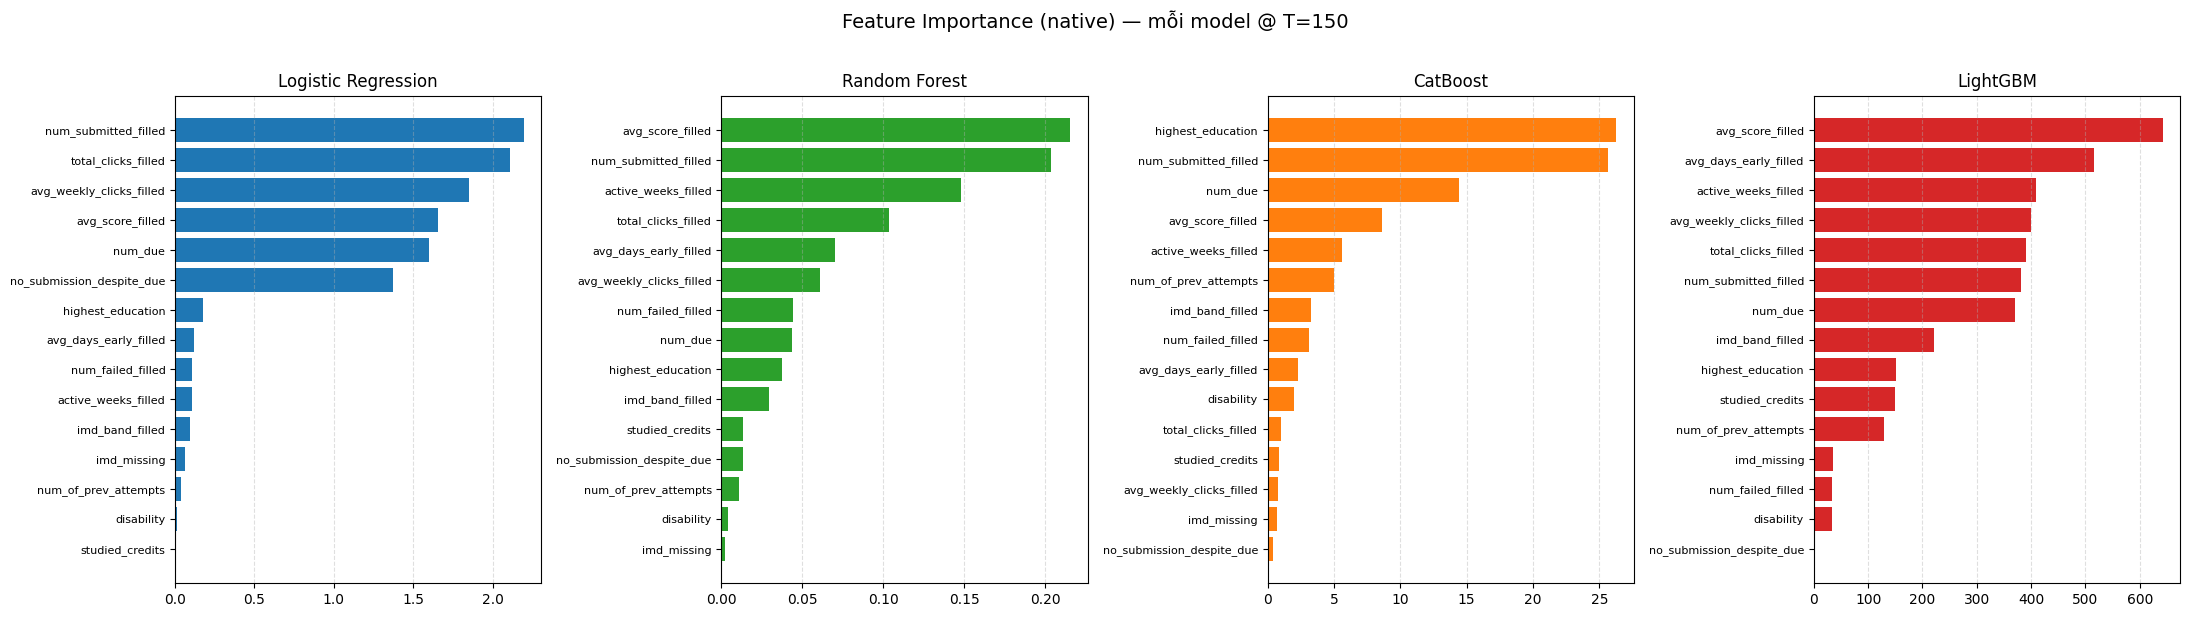

--- Thứ hạng feature theo từng model (1 = quan trọng nhất) ---


,Logistic Regression,Random Forest,CatBoost,LightGBM,mean_rank
avg_score_filled,4,1,4,1,2.50
num_submitted_filled,1,2,2,6,2.75
active_weeks_filled,10,3,5,3,5.25
total_clicks_filled,2,4,11,5,5.50
num_due,5,8,3,7,5.75
avg_days_early_filled,8,5,9,2,6.00
avg_weekly_clicks_filled,3,6,13,4,6.50
highest_education,7,9,1,9,6.50
imd_band_filled,11,10,7,8,9.00
num_failed_filled,9,7,8,13,9.25


In [7]:
colors = ['tab:blue', 'tab:green', 'tab:orange', 'tab:red']

fig, axes = plt.subplots(1, len(importance_by_model), figsize=(22, 6), sharey=False)

for ax, color, (name, s) in zip(axes, colors, importance_by_model.items()):
    s_sorted = s.sort_values()
    ax.barh(s_sorted.index, s_sorted.values, color=color)
    ax.set_title(name, fontsize=12)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.suptitle('Feature Importance (native) — mỗi model @ T=150', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'feature_importance_native.png', dpi=150, bbox_inches='tight')
plt.show()

# Thứ hạng feature mỗi model (1 = quan trọng nhất) + hạng trung bình
ranks = pd.DataFrame(
    {name: s.rank(ascending=False).astype(int) for name, s in importance_by_model.items()},
    index=FEATURE_NAMES,
)
ranks['mean_rank'] = ranks.mean(axis=1).round(2)
ranks = ranks.sort_values('mean_rank')
print('--- Thứ hạng feature theo từng model (1 = quan trọng nhất) ---')
ranks

---

## Train lại với Top-10 & Top-5 features

Chọn các feature có `mean_rank` tốt nhất (quan trọng xuyên suốt 4 model) rồi chạy lại **đúng pipeline fine-tune** (Optuna + SMOTE + class_weight, tối ưu F1 At-risk) cho cả 4 model trên **hai bộ feature rút gọn cùng lúc: Top-10 và Top-5**. So sánh với bản full-feature để xem hiệu suất có **ổn định** không khi cắt bớt feature.

Confusion matrix của mọi tổ hợp (feature-set × model) được gom thành **lưới subplot** (2 hàng × 4 cột) để so sánh trực tiếp.

> ⚠️ Cell train chạy nặng: 2 bộ feature × 4 model × Optuna × 3-fold (SMOTE mỗi fold).

In [8]:
from IPython.display import display

feature_sets = {
    'Top-10': list(ranks.index[:10]),
    'Top-5':  list(ranks.index[:5]),
}

trained_models_by_set = {}
comparison_by_set      = {}

for set_label, feats in feature_sets.items():
    print(f'\n{"="*60}\n  FEATURE SET: {set_label}  ({len(feats)} features)\n{"="*60}')
    for i, f in enumerate(feats, 1):
        print(f'  {i:2d}. {f}')

    CURRENT_SET = set_label
    X_tr_set, X_te_set = X_train[feats], X_test[feats]
    rows, models = [], {}
    for name, cfg in MODEL_CONFIGS.items():
        print(f'\n--- FINE-TUNE ({set_label}): {name} ---')
        row, model_obj = tune_and_evaluate(
            name, cfg, X_tr_set, y_train, X_te_set, y_test, plot_cm=False,
        )
        rows.append(row)
        models[name] = model_obj
    trained_models_by_set[set_label] = models
    comparison_by_set[set_label] = (
        pd.DataFrame(rows).set_index('model').sort_values('f1', ascending=False)
    )

# Giữ tên biến cũ để các cell phía sau (so sánh, SHAP) dùng lại được
trained_models_top  = trained_models_by_set['Top-10']
trained_models_top5 = trained_models_by_set['Top-5']
comparison_top_df   = comparison_by_set['Top-10']
comparison_top5_df  = comparison_by_set['Top-5']

top10, top5 = feature_sets['Top-10'], feature_sets['Top-5']
X_train_top,  X_test_top  = X_train[top10], X_test[top10]
X_train_top5, X_test_top5 = X_train[top5],  X_test[top5]

print('\n--- So sánh model (Top-10 features) ---')
display(style_max(comparison_top_df))
print('--- So sánh model (Top-5 features) ---')
display(style_max(comparison_top5_df))


  FEATURE SET: Top-10  (10 features)
   1. avg_score_filled
   2. num_submitted_filled
   3. active_weeks_filled
   4. total_clicks_filled
   5. num_due
   6. avg_days_early_filled
   7. avg_weekly_clicks_filled
   8. highest_education
   9. imd_band_filled
  10. num_failed_filled

--- FINE-TUNE (Top-10): Logistic Regression ---


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.7772
SMOTE → At-risk: +0.62x | class_weight At-risk: 1.11


              precision    recall  f1-score   support

        Pass      0.873     0.854     0.864      2804
     At-risk      0.748     0.777     0.762      1559

    accuracy                          0.827      4363
   macro avg      0.811     0.816     0.813      4363
weighted avg      0.829     0.827     0.827      4363

ROC-AUC: 0.8968

--- FINE-TUNE (Top-10): Random Forest ---


  0%|          | 0/30 [00:00<?, ?it/s]

...

Best F1 At-risk CV: 0.7875
SMOTE → At-risk: +0.61x | class_weight At-risk: 1.67


              precision    recall  f1-score   support

        Pass      0.881     0.859     0.870      2804
     At-risk      0.758     0.792     0.775      1559

    accuracy                          0.835      4363
   macro avg      0.820     0.826     0.822      4363
weighted avg      0.837     0.835     0.836      4363

ROC-AUC: 0.9060

--- So sánh model (Top-10 features) ---


,accuracy,precision,recall,f1,roc_auc
model,,,,,
CatBoost,0.8485,0.7966,0.7736,0.7849,0.9122
LightGBM,0.8377,0.7631,0.7915,0.7771,0.9087
Random Forest,0.8398,0.7728,0.7813,0.7770,0.9075
Logistic Regression,0.8267,0.7477,0.7774,0.7623,0.8968


--- So sánh model (Top-5 features) ---


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Random Forest,0.8496,0.8082,0.7595,0.7831,0.9071
CatBoost,0.8457,0.7892,0.7755,0.7823,0.9089
LightGBM,0.8352,0.7577,0.7922,0.7745,0.9060
Logistic Regression,0.8205,0.7360,0.7761,0.7555,0.8952


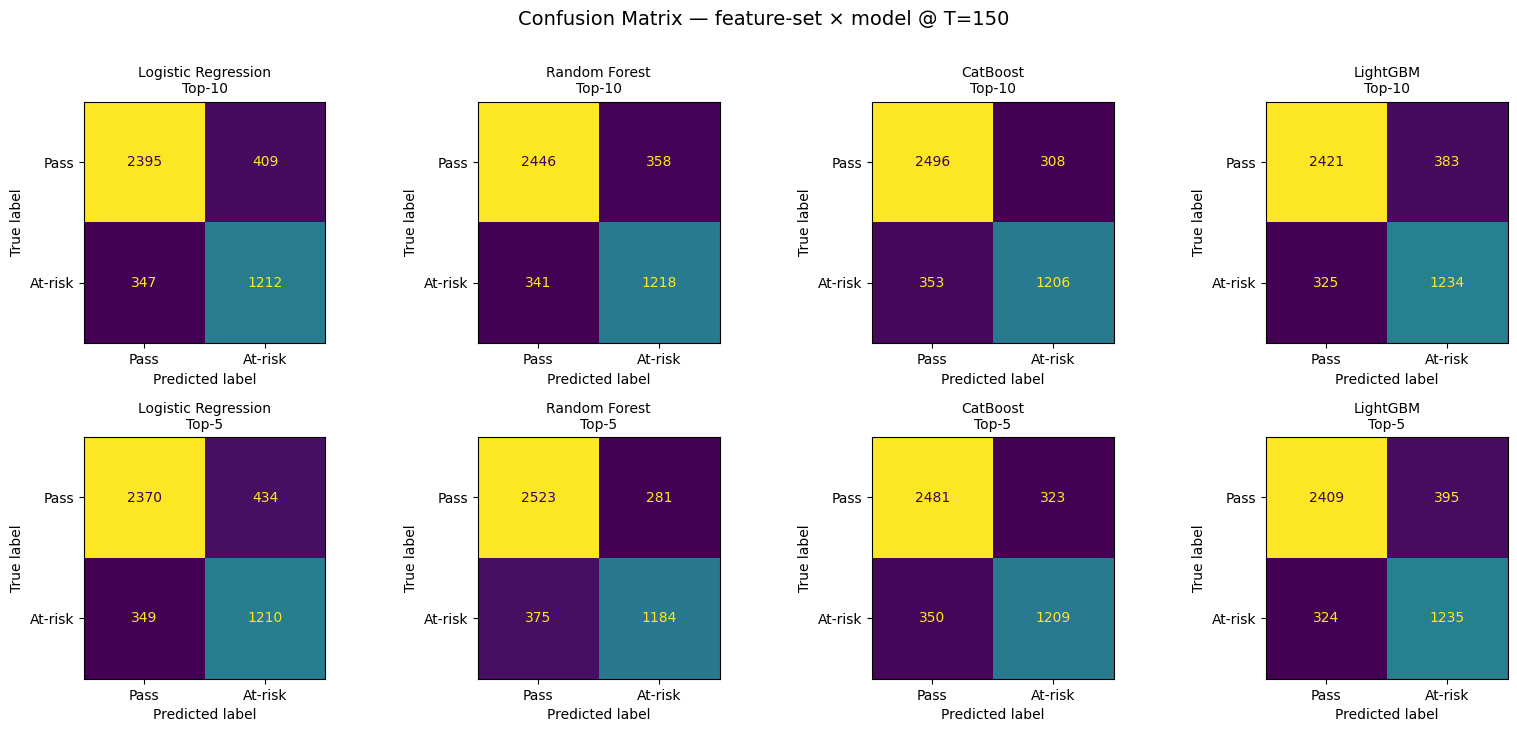

In [9]:
# Confusion matrix: mọi (feature-set × model) gom chung 1 lưới subplot để so sánh
model_order = list(MODEL_CONFIGS)
set_order   = list(feature_sets)

fig, axes = plt.subplots(
    len(set_order), len(model_order),
    figsize=(4 * len(model_order), 3.6 * len(set_order)),
)

for r, set_label in enumerate(set_order):
    Xte = np.asarray(X_test[feature_sets[set_label]])
    for c, name in enumerate(model_order):
        scaler, model = trained_models_by_set[set_label][name]
        X_in   = scaler.transform(Xte) if scaler is not None else Xte
        y_pred = model.predict(X_in)
        cm     = confusion_matrix(y_test, y_pred, labels=CLASSES)
        ax = axes[r, c]
        ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES).plot(ax=ax, colorbar=False)
        ax.set_title(f'{name}\n{set_label}', fontsize=10)

plt.suptitle('Confusion Matrix — feature-set × model @ T=150', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'cm_grid_topn.png', dpi=150, bbox_inches='tight')
plt.show()

--- Full(15) vs Top-10 vs Top-5 ---
                    Full(15)                                     Top-10  \
                    accuracy precision  recall      f1 roc_auc accuracy   
model                                                                     
Logistic Regression   0.8265    0.7574  0.7569  0.7571  0.8975   0.8267   
Random Forest         0.8405    0.7733  0.7832  0.7782  0.9071   0.8398   
CatBoost              0.8515    0.8039  0.7729  0.7881  0.9126   0.8485   
LightGBM              0.8439    0.7884  0.7697  0.7790  0.9108   0.8377   

                                                         Top-5            \
                    precision  recall      f1 roc_auc accuracy precision   
model                                                                      
Logistic Regression    0.7477  0.7774  0.7623  0.8968   0.8205    0.7360   
Random Forest          0.7728  0.7813  0.7770  0.9075   0.8496    0.8082   
CatBoost               0.7966  0.7736  0.7849  0.9122   0.

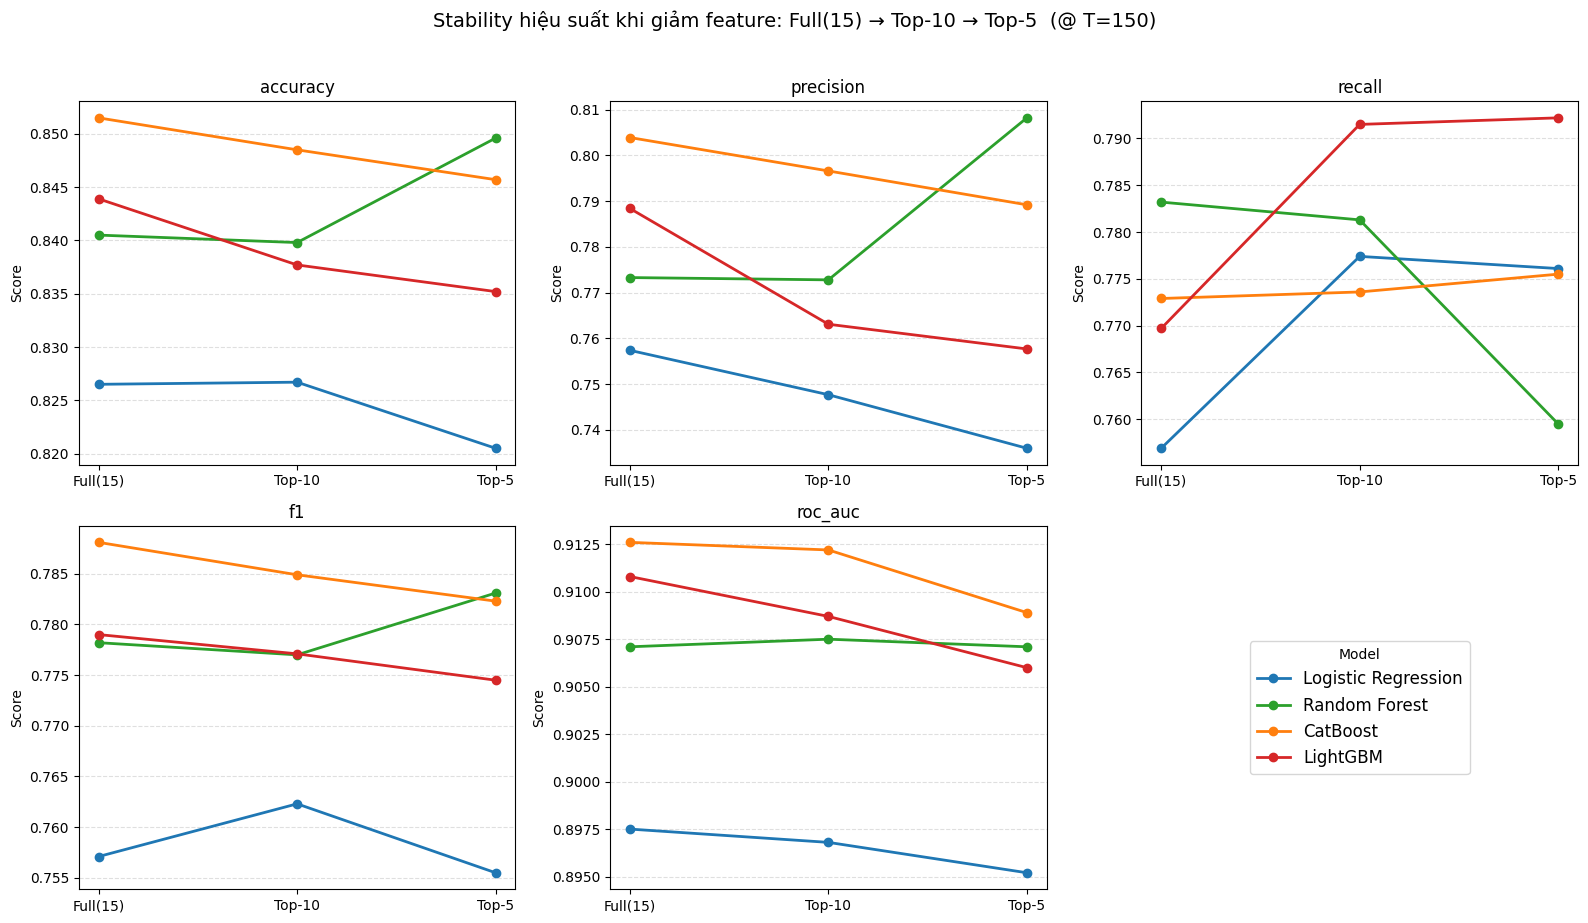

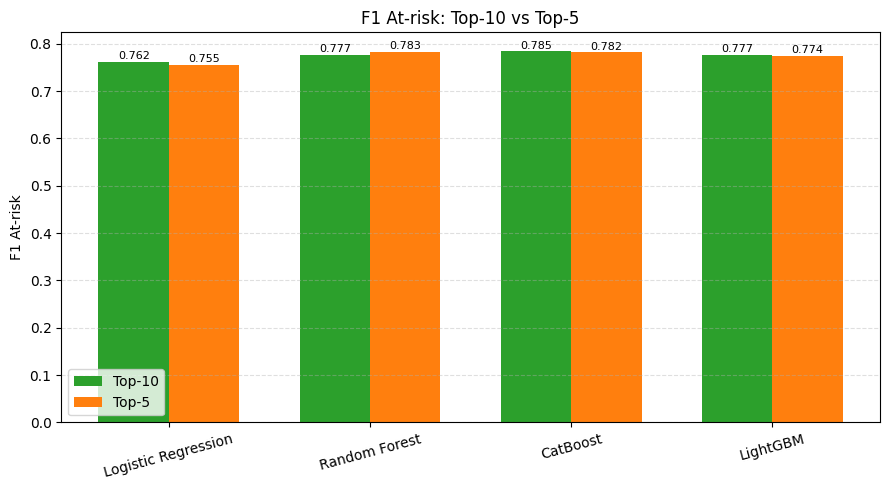

In [10]:
model_order = list(MODEL_CONFIGS)
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

full = comparison_df.reindex(model_order)
t10  = comparison_top_df.reindex(model_order)
t5   = comparison_top5_df.reindex(model_order)

# --- Bảng tổng hợp 3 feature-set ---
combined3 = pd.concat({'Full(15)': full, 'Top-10': t10, 'Top-5': t5}, axis=1)
print('--- Full(15) vs Top-10 vs Top-5 ---')
print(combined3)
print('\nΔ (Top-5 − Top-10):')
print((t5 - t10).round(4))

# --- Trực quan hóa: mỗi metric 1 subplot, x = feature-set, line per model ---
xsets = ['Full(15)', 'Top-10', 'Top-5']
data  = {'Full(15)': full, 'Top-10': t10, 'Top-5': t5}
mcolors = ['tab:blue', 'tab:green', 'tab:orange', 'tab:red']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()
for ax, metric in zip(axes, metrics):
    for name, c in zip(model_order, mcolors):
        ys = [data[s].loc[name, metric] for s in xsets]
        ax.plot(xsets, ys, marker='o', linewidth=2, color=c, label=name)
    ax.set_title(metric, fontsize=12)
    ax.set_ylabel('Score')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

# ô thứ 6 dùng làm legend
axes[-1].axis('off')
handles, labels = axes[0].get_legend_handles_labels()
axes[-1].legend(handles, labels, loc='center', fontsize=12, title='Model')

plt.suptitle('Stability hiệu suất khi giảm feature: Full(15) → Top-10 → Top-5  (@ T=150)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'stability_featureset.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Bar chart riêng cho F1 At-risk (so sánh trực tiếp Top-10 vs Top-5) ---
x = np.arange(len(model_order))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, t10['f1'].values, w, label='Top-10', color='tab:green')
ax.bar(x + w/2, t5['f1'].values,  w, label='Top-5',  color='tab:orange')
for i, (a, b) in enumerate(zip(t10['f1'].values, t5['f1'].values)):
    ax.text(i - w/2, a + 0.005, f'{a:.3f}', ha='center', fontsize=8)
    ax.text(i + w/2, b + 0.005, f'{b:.3f}', ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(model_order, rotation=15)
ax.set_ylabel('F1 At-risk')
ax.set_title('F1 At-risk: Top-10 vs Top-5')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / 'f1_top10_vs_top5.png', dpi=150, bbox_inches='tight')
plt.show()

---

## SHAP — Explainable AI (model tốt nhất, cả 3 feature set)

Chọn **model tốt nhất theo F1 At-risk** (full-feature), giải thích bằng SHAP trên **cả 3 bộ feature** (Full / Top-10 / Top-5) để xem feature nào đẩy dự đoán về **At-risk**.

- Tree models (RF/CatBoost/LightGBM) → `TreeExplainer`; Logistic Regression → `LinearExplainer` (trên dữ liệu đã scale).
- **Beeswarm**: mỗi điểm là 1 sinh viên; màu = giá trị feature; trục x = SHAP value (>0 đẩy về **At-risk**, <0 đẩy về **Pass**).
- **Bar**: mean(|SHAP|) — độ quan trọng tổng thể của feature.
- Chạy trên mẫu test (`SHAP_SAMPLE`) cho nhanh & dễ đọc.

In [11]:
import shap

SHAP_SAMPLE = 2000  # số mẫu test dùng cho SHAP (giảm nếu chậm)
BEST_MODEL  = comparison_df['f1'].idxmax()
print(f'Model tốt nhất theo F1 At-risk: {BEST_MODEL}')


SHAP_SUFFIX = {'Full (15)': 'full', 'Top-10': 'top10', 'Top-5': 'top5'}


def shap_explain(set_label, models_dict, X_te_set, feat_names):
    scaler, model = models_dict[BEST_MODEL]

    Xs = X_te_set
    if len(Xs) > SHAP_SAMPLE:
        Xs = Xs.sample(SHAP_SAMPLE, random_state=RANDOM_SEED)

    if scaler is not None:  # LogReg → SHAP trên dữ liệu đã scale
        X_input = pd.DataFrame(scaler.transform(Xs), columns=feat_names, index=Xs.index)
        explainer = shap.LinearExplainer(model, X_input)
    else:                   # tree models
        X_input = Xs
        explainer = shap.TreeExplainer(model)

    sv = explainer(X_input)
    if sv.values.ndim == 3:        # phòng trường hợp trả (n, feat, 2) → lấy lớp At-risk
        sv = sv[..., 1]

    print(f'\n{"="*55}\n  SHAP — {BEST_MODEL}  |  {set_label} ({len(feat_names)} features)\n{"="*55}')
    # shap.plots.* ve len figure hien hanh -> phai dong truoc/sau moi lan ve,
    # neu khong cac bieu do se chong len nhau khi chay headless.
    sfx = SHAP_SUFFIX[set_label]
    plt.close('all')
    shap.plots.beeswarm(sv, max_display=len(feat_names), show=False)
    plt.title(f'SHAP beeswarm — {set_label}', fontsize=12)
    plt.savefig(FIG_DIR / f'shap_beeswarm_{sfx}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close('all')
    shap.plots.bar(sv, max_display=len(feat_names), show=False)
    plt.title(f'SHAP mean|value| — {set_label}', fontsize=12)
    plt.savefig(FIG_DIR / f'shap_bar_{sfx}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close('all')
    return sv

Model tốt nhất theo F1 At-risk: CatBoost



  SHAP — CatBoost  |  Full (15) (15 features)


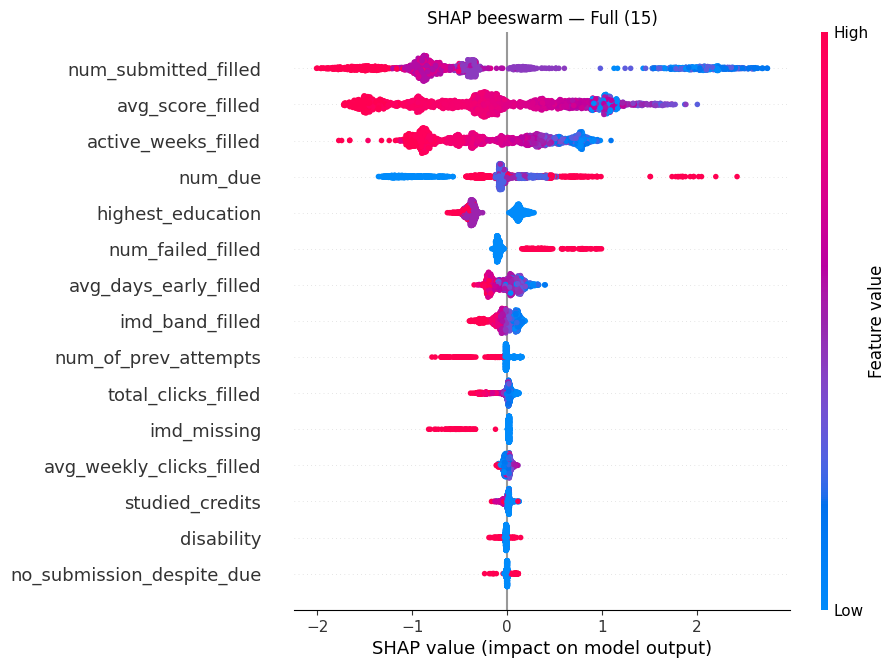

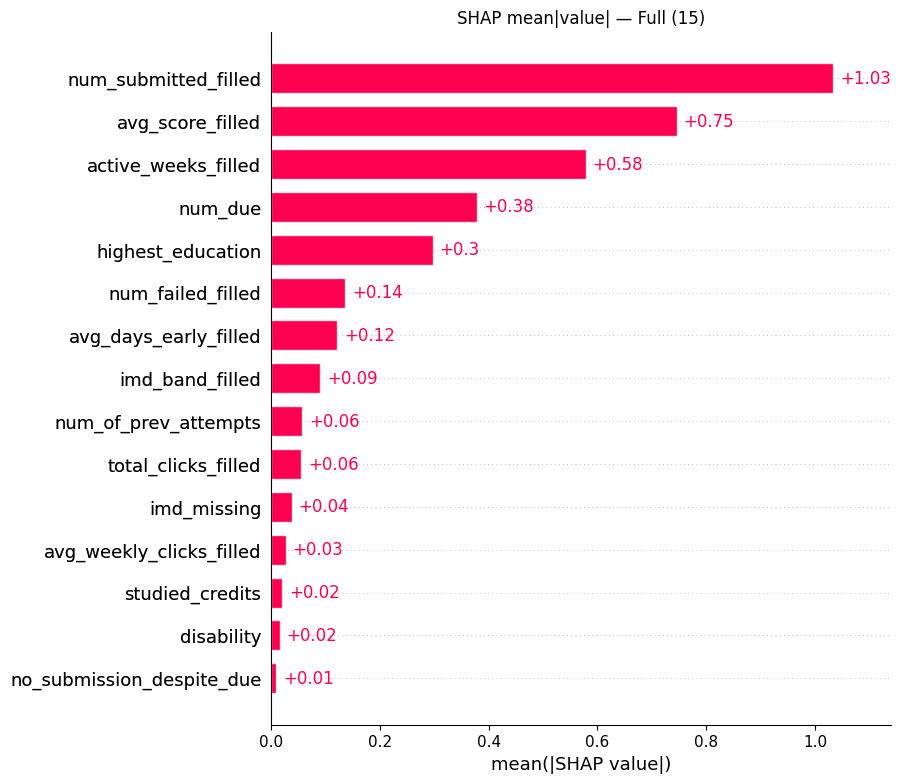


  SHAP — CatBoost  |  Top-10 (10 features)


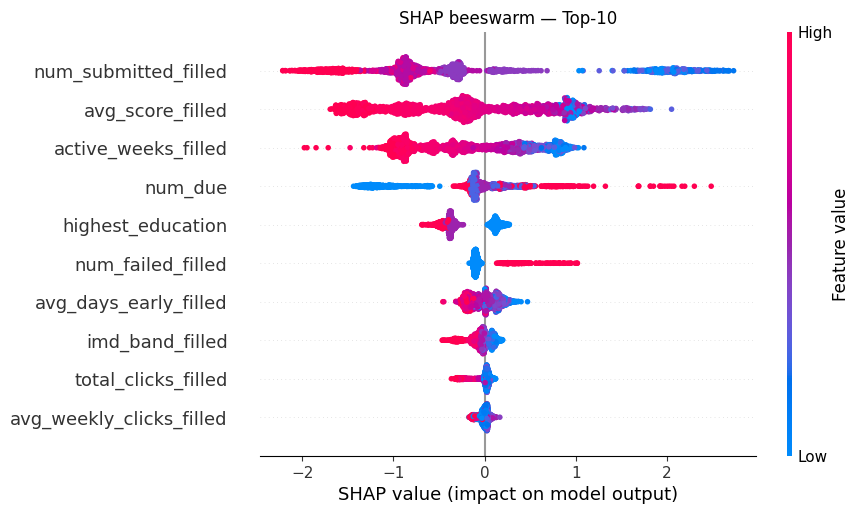

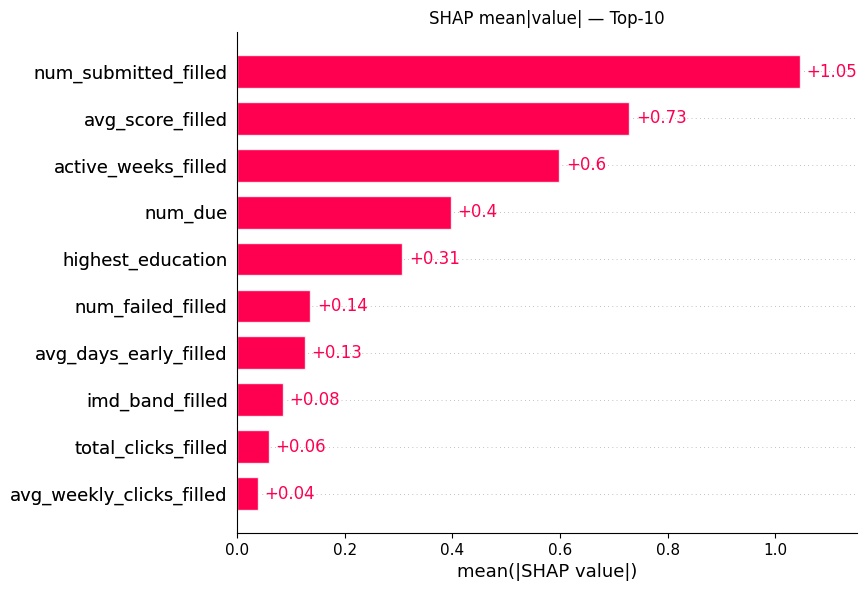


  SHAP — CatBoost  |  Top-5 (5 features)


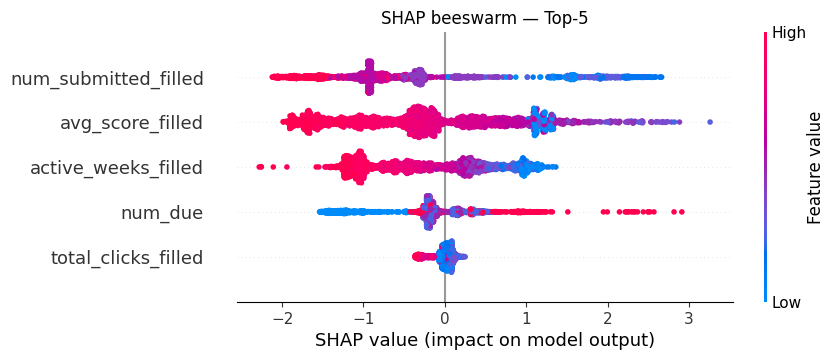

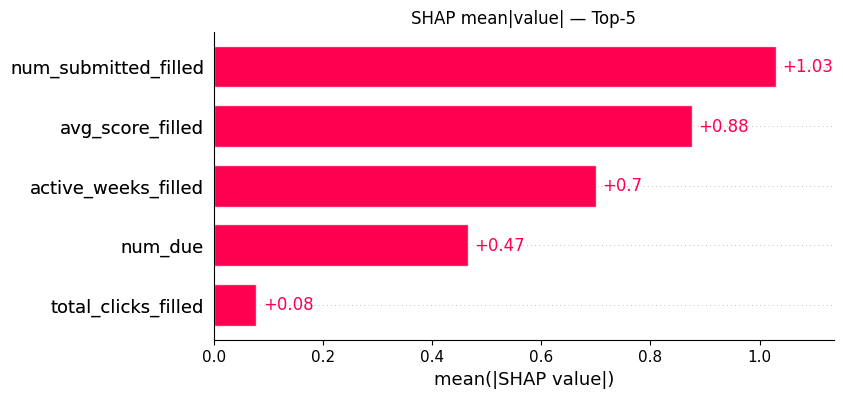

In [12]:
sv_full = shap_explain('Full (15)', trained_models,      X_test,      FEATURE_NAMES)
sv_t10  = shap_explain('Top-10',    trained_models_top,  X_test_top,  top10)
sv_t5   = shap_explain('Top-5',     trained_models_top5, X_test_top5, top5)

### Giải thích cục bộ — waterfall (vài ca cụ thể)

Waterfall cho thấy từng feature đẩy dự đoán của **một sinh viên** lên/xuống quanh giá trị nền (base value), trên model tốt nhất với bộ Full-feature.


  Waterfall — Đẩy mạnh về At-risk (mẫu #1729)


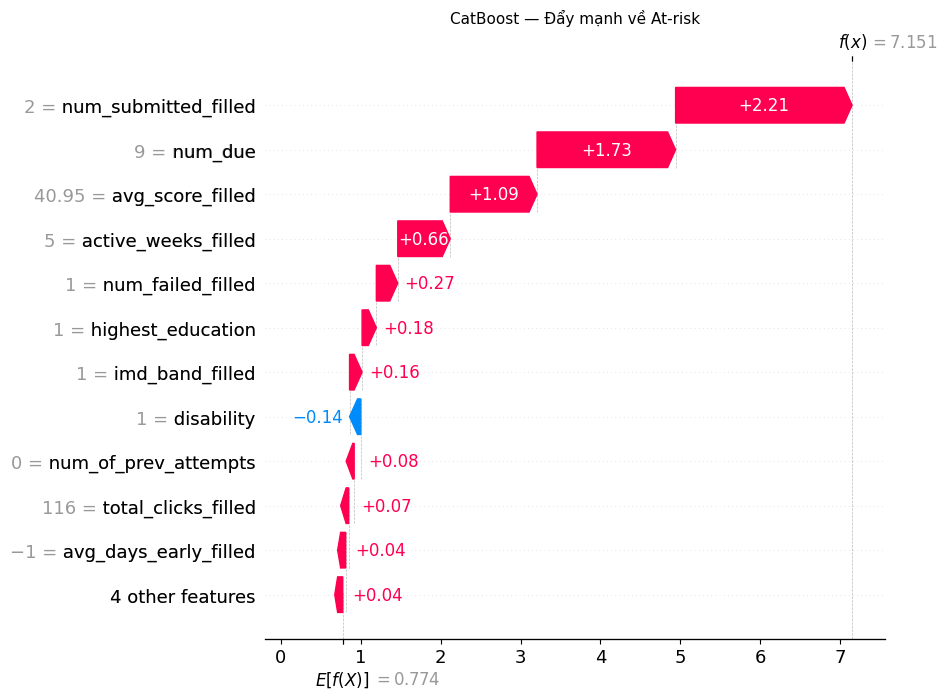


  Waterfall — Đẩy mạnh về Pass (mẫu #1450)


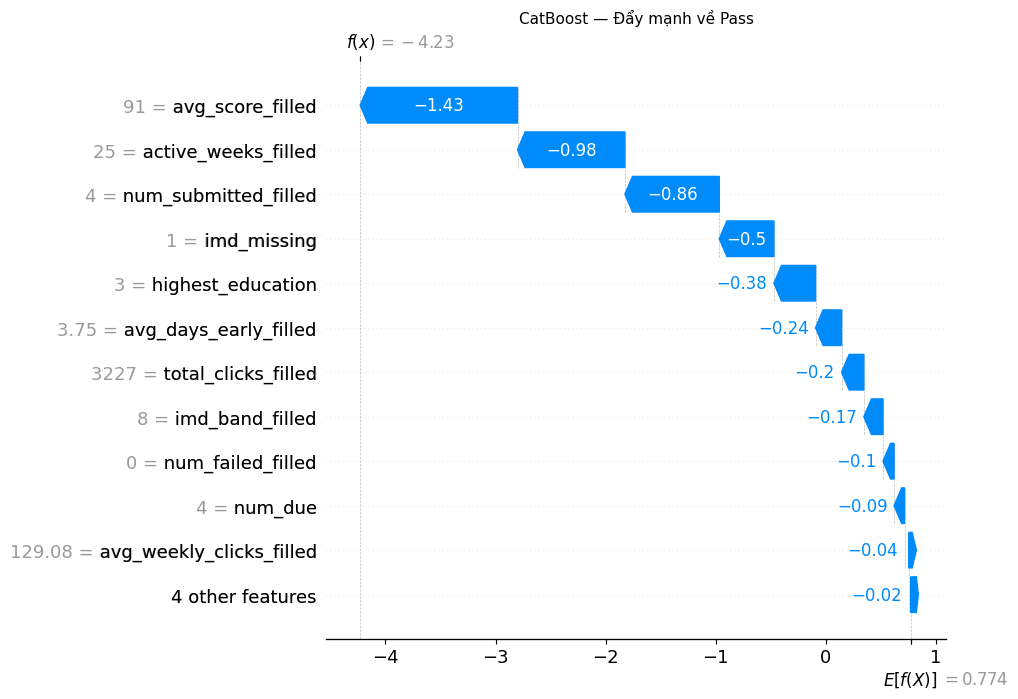

In [13]:
# Chọn 2 ca: 1 SHAP-sum cao nhất (đẩy mạnh về At-risk) và 1 thấp nhất (đẩy mạnh về Pass)
order = np.argsort(sv_full.values.sum(axis=1))
examples = {
    'Đẩy mạnh về At-risk': (int(order[-1]), 'waterfall_atrisk.png'),
    'Đẩy mạnh về Pass':    (int(order[0]),  'waterfall_pass.png'),
}

for label, (idx, fname) in examples.items():
    print(f'\n{"="*55}\n  Waterfall — {label} (mẫu #{idx})\n{"="*55}')
    plt.close('all')
    shap.plots.waterfall(sv_full[idx], max_display=12, show=False)
    plt.title(f'{BEST_MODEL} — {label}', fontsize=11)
    plt.savefig(FIG_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close('all')


In [14]:
# Xuất toàn bộ kết quả số ra JSON để sinh bảng LaTeX cho báo cáo (không chép tay)
import json

results = {
    'prediction_point': PREDICTION_POINT,
    'best_model': BEST_MODEL,
    'split': {
        'train': {'pass': int((y_train == 0).sum()), 'at_risk': int((y_train == 1).sum()),
                  'total': int(len(y_train))},
        'test':  {'pass': int((y_test == 0).sum()),  'at_risk': int((y_test == 1).sum()),
                  'total': int(len(y_test))},
    },
    'compare': {
        'full':  comparison_df.to_dict(orient='index'),
        'top10': comparison_top_df.to_dict(orient='index'),
        'top5':  comparison_top5_df.to_dict(orient='index'),
    },
    'ranks': ranks.to_dict(orient='index'),
    'tuning': TUNING_LOG,
    'feature_sets': {'top10': top10, 'top5': top5, 'full': FEATURE_NAMES},
}

out = RES_DIR / 'results_t150.json'
out.write_text(json.dumps(results, ensure_ascii=False, indent=2), encoding='utf-8')
print('Wrote', out.resolve())
print(json.dumps(results['compare']['full'], ensure_ascii=False, indent=2))


Wrote D:\My Stuff\VinGroup Course\Internship VSF\early-academic-risk-warning\full_report\results_t150.json
{
  "CatBoost": {
    "accuracy": 0.8515,
    "precision": 0.8039,
    "recall": 0.7729,
    "f1": 0.7881,
    "roc_auc": 0.9126
  },
  "LightGBM": {
    "accuracy": 0.8439,
    "precision": 0.7884,
    "recall": 0.7697,
    "f1": 0.779,
    "roc_auc": 0.9108
  },
  "Random Forest": {
    "accuracy": 0.8405,
    "precision": 0.7733,
    "recall": 0.7832,
    "f1": 0.7782,
    "roc_auc": 0.9071
  },
  "Logistic Regression": {
    "accuracy": 0.8265,
    "precision": 0.7574,
    "recall": 0.7569,
    "f1": 0.7571,
    "roc_auc": 0.8975
  }
}
